In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


In [2]:
# ====================== НАСТРОЙКИ ПУТЕЙ ======================
base_dir = r'C:\Poly\Диплом'
vis_dir = os.path.join(base_dir, 'Визуализация')
preproc_dir = os.path.join(base_dir, 'Предобработанные данные')

os.makedirs(vis_dir, exist_ok=True)
os.makedirs(preproc_dir, exist_ok=True)

print("Папки созданы:\n", vis_dir, "\n", preproc_dir)

# ====================== ЗАГРУЗКА ДАННЫХ ======================
matches_path = os.path.join(base_dir, r'Данные по матчам 2014-2023', 'football_matches_dataset.csv')
players_path = os.path.join(base_dir, r'Трансферные стоимости', 'players.csv')
valuations_path = os.path.join(base_dir, r'Трансферные стоимости', 'player_valuations.csv')
attrs_path = os.path.join(base_dir, r'Атрибуты игроков 2023', 'male_players.csv')

matches = pd.read_csv(matches_path)
players = pd.read_csv(players_path)
valuations = pd.read_csv(valuations_path)
attrs = pd.read_csv(attrs_path)

attrs['update_as_of'] = pd.to_datetime(attrs['update_as_of'], errors='coerce')
attrs = attrs[attrs['update_as_of'].dt.year == 2023].copy()

print("Данные загружены. Формы:")
print("matches:", matches.shape)
print("players:", players.shape)
print("valuations:", valuations.shape)
print("attrs:", attrs.shape)

Папки созданы:
 C:\Poly\Диплом\Визуализация 
 C:\Poly\Диплом\Предобработанные данные
Данные загружены. Формы:
matches: (16332, 55)
players: (34376, 23)
valuations: (525510, 6)
attrs: (18350, 109)


In [3]:
# ====================== КОНВЕРТАЦИЯ СТОИМОСТИ В ЧИСЛА ======================
for col in ['value_eur']:
    if col in attrs.columns:
        attrs[col] = attrs[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
        attrs[col] = pd.to_numeric(attrs[col], errors='coerce')
        
# ====================== ПРЕДОБРАБОТКА ======================
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
if 'datetime' in matches.columns:
    matches['datetime'] = pd.to_datetime(matches['datetime'])
    
matches['total_goals'] = matches['home_score'] + matches['away_score']
matches['is_draw'] = (matches['home_score'] == matches['away_score']).astype(int)

# Импутация xG медианой
xg_median = matches[['home_xg', 'away_xg']].median().iloc[0]
matches['home_xg'] = matches['home_xg'].fillna(xg_median)
matches['away_xg'] = matches['away_xg'].fillna(xg_median)

matches.to_csv(os.path.join(preproc_dir, 'matches_preprocessed.csv'), index=False)
players.to_csv(os.path.join(preproc_dir, 'players_preprocessed.csv'), index=False)
attrs.to_csv(os.path.join(preproc_dir, 'player_attributes_preprocessed.csv'), index=False)
valuations.to_csv(os.path.join(preproc_dir, 'player_valuations_preprocessed.csv'), index=False)
print("Предобработанные файлы сохранены в:\n", preproc_dir)

Предобработанные файлы сохранены в:
 C:\Poly\Диплом\Предобработанные данные


In [4]:
# ====================== EDA И ТАБЛИЦЫ ======================

# ТАБЛИЦА 1
table1 = matches.groupby('league').agg(
    Матчей=('league', 'count'),
    Ср_кол_во_голов_дома=('home_score', 'mean'),
    Ср_кол_во_голов_на_выезде=('away_score', 'mean'),
    Общая_результативность=('total_goals', 'mean'),
    Процент_ничьих=('is_draw', lambda x: round(x.mean()*100, 1))
).round(3)

table1.to_csv(os.path.join(vis_dir, 'Таблица_1_статистика_голов_по_лигам.csv'))
print("\nТАБЛИЦА 1:")
display(table1)


ТАБЛИЦА 1:


,Матчей,Ср_кол_во_голов_дома,Ср_кол_во_голов_на_выезде,Общая_результативность,Процент_ничьих
league,,,,,
Bundesliga,2754,1.684,1.311,2.995,24.7
EPL,3420,1.520,1.219,2.739,23.5
La liga,3420,1.500,1.125,2.625,25.8
Ligue 1,3318,1.484,1.165,2.649,25.8
Serie A,3420,1.527,1.263,2.789,25.3


In [5]:
# ТАБЛИЦА 2
table2 = matches.groupby('league').agg(
    Ср_xG_дома=('home_xg', 'mean'),
    Ср_xG_на_выезде=('away_xg', 'mean'),
    Общая_xG_за_матч=('home_xg', lambda x: x.mean() + matches.loc[x.index, 'away_xg'].mean())
).round(3)

table2.to_csv(os.path.join(vis_dir, 'Таблица_2_распределение_xG.csv'))
print("\nТАБЛИЦА 2:")
display(table2)



ТАБЛИЦА 2:


,Ср_xG_дома,Ср_xG_на_выезде,Общая_xG_за_матч
league,,,
Bundesliga,1.623,1.287,2.911
EPL,1.516,1.214,2.730
La liga,1.522,1.132,2.654
Ligue 1,1.448,1.137,2.585
Serie A,1.506,1.237,2.743


In [6]:
# ====================== ТАБЛИЦА 3 ======================

# Маппинг позиций в русские категории
def categorize_position(pos):
    pos = str(pos).upper()
    if 'GOALKEEPER' in pos or 'GK' in pos:
        return 'Вратари'
    elif any(x in pos for x in ['DEFENDER', 'BACK', 'CB', 'LB', 'RB', 'DF']):
        return 'Защитники'
    elif any(x in pos for x in ['MIDFIELD', 'CM', 'CAM', 'DM', 'MF']):
        return 'Полузащитники'
    else:
        return 'Нападающие'

attrs['pos_cat'] = attrs['player_positions'].apply(categorize_position)

table3 = attrs.groupby('pos_cat').agg(
    Медианный_возраст=('age', 'median'),
    Медианный_рост=('height_cm', 'median'),
).round(1)

table3 = table3.reindex(['Вратари', 'Защитники', 'Полузащитники', 'Нападающие']) 
table3.index.name = None

table3.to_csv(os.path.join(vis_dir, 'Таблица_3_возраст_по_позициям.csv'))

print("\nТАБЛИЦА 3. Распределение возраста по позициям")
display(table3)


ТАБЛИЦА 3. Распределение возраста по позициям


,Медианный_возраст,Медианный_рост
Вратари,26.0,189.0
Защитники,25.0,183.0
Полузащитники,24.0,178.0
Нападающие,24.0,180.0


In [7]:
# ТАБЛИЦА 4 (Пуассон для АПЛ)
epl = matches[matches['league'] == 'EPL'].copy() if 'EPL' in matches['league'].unique() else matches[matches['league'].str.contains('Premier', na=False)].copy()
if len(epl) > 0:
    lambda_poisson = epl['home_score'].mean()
    obs_counts = epl['home_score'].value_counts().sort_index()
    max_k = 5
    k = np.arange(0, max_k + 1)
    expected = stats.poisson.pmf(k, lambda_poisson) * len(epl)
    expected_5plus = (1 - stats.poisson.cdf(max_k, lambda_poisson)) * len(epl)
    
    fact = [obs_counts.get(i, 0) for i in k] + [len(epl) - sum([obs_counts.get(i, 0) for i in k])]
    exp = list(expected) + [expected_5plus]
    
    table3 = pd.DataFrame({
        'Количество голов': list(range(max_k + 1)) + ['5+'],
        'Факт матчей': fact,
        'Ожид матчей Пуассон': [round(e, 1) for e in exp],
        'Вклад в хи2': [round((o - e)**2 / e, 2) if e > 0 else 0 for o, e in zip(fact, exp)]
    })
    chi2_total = round(sum(table3['Вклад в хи2']), 2)
    table3.to_csv(os.path.join(vis_dir, 'Таблица_3_Пуассон_АПЛ.csv'))
    print(f"\nТАБЛИЦА 4 (χ² = {chi2_total}):")
    display(table3)
else:
    print("Лига EPL не найдена. Проверьте matches['league'].unique() и замените фильтр.")



ТАБЛИЦА 4 (χ² = 25.15):


,Количество голов,Факт матчей,Ожид матчей Пуассон,Вклад в хи2
0,0,815,748.1,5.99
1,1,1104,1137.0,0.96
2,2,815,864.1,2.78
3,3,418,437.8,0.89
4,4,174,166.3,0.35
5,5,65,50.6,4.12
6,5+,29,16.2,10.06


In [8]:
# ====================== ТАБЛИЦА 4 (Корреляция командных метрик с голами) ======================

corr_metrics = [
    'home_xg',                      # Ожидаемые голы (xG)
    'home_attack_rating',           # Общая атака (замена "Общее кол-во ударов")
    'home_mean_xg_last_4_matches',  # Средний xG за последние 4 матча
    'home_midfield_rating',         # Рейтинг полузащиты (лучший прокси для владения и точных передач)
    'home_attack_rating_last_4_matches',  # Атака за последние 4 матча
    'home_score'                    # Целевая переменная
]

corr_matrix = matches[corr_metrics].corr(method='pearson').round(2)

table4 = corr_matrix['home_score'].drop('home_score').reset_index()
table4.columns = ['Метрика', 'Корреляция с голами (ρ)']

# Переименовываем метрики в красивый русский вид
rename_dict = {
    'home_xg': 'Ожидаемые голы (xG)',
    'home_attack_rating': 'Рейтинг атаки',
    'home_mean_xg_last_4_matches': 'xG за последние 4 матча',
    'home_midfield_rating': 'Рейтинг полузащиты (владение/передачи)',
    'home_attack_rating_last_4_matches': 'Рейтинг атаки за последние 4 матча'
}
table4['Метрика'] = table4['Метрика'].map(rename_dict)

table4.to_csv(os.path.join(vis_dir, 'Таблица_4_корреляции_с_голами.csv'), index=False)

print("\nТАБЛИЦА 4. Корреляция командных метрик с количеством забитых голов:")
display(table4)


ТАБЛИЦА 4. Корреляция командных метрик с количеством забитых голов:


,Метрика,Корреляция с голами (ρ)
0,Ожидаемые голы (xG),0.63
1,Рейтинг атаки,0.75
2,xG за последние 4 матча,0.24
3,Рейтинг полузащиты (владение/передачи),0.62
4,Рейтинг атаки за последние 4 матча,0.20


In [9]:
# ====================== ТАБЛИЦА 5. Детерминанты рыночной стоимости ======================

skill_cols = ['overall', 'potential', 'age', 'height_cm', 'physic', 'value_eur',
                   'dribbling', 'shooting', 'defending', 'pace']

for col in skill_cols:
    if col in attrs.columns:
        attrs[col] = attrs[col].astype(str)
        attrs[col] = attrs[col].str.replace(r'[^0-9.\-]', '', regex=True)
        attrs[col] = attrs[col].replace('', np.nan)
        attrs[col] = pd.to_numeric(attrs[col], errors='coerce')

player_features = ['overall', 'potential', 'age', 'height_cm', 'physic', 'value_eur',
                   'dribbling', 'shooting', 'defending', 'pace']

df_corr = attrs[player_features].dropna(thresh=5)

corr_player = df_corr.corr(method='pearson')['value_eur'].round(2).sort_values(ascending=False)

table5 = corr_player.drop('value', errors='ignore').reset_index()
table5.columns = ['Признак', 'Корреляция со стоимостью']

rename_dict = {
    'overall': 'Общий рейтинг',
    'potential': 'Потенциал',
    'age': 'Возраст',
    'height_cm': 'Рост (см)',
    'physic': 'Физическая форма',
    'dribbling': 'Дриблинг',
    'shooting': 'Удары',
    'defending': 'Оборона',
    'pace': 'Скорость'
}
table5['Признак'] = table5['Признак'].map(rename_dict).fillna(table5['Признак'])

table5.to_csv(os.path.join(vis_dir, 'Таблица_5_детерминанты_стоимости.csv'), index=False)

print("\nТАБЛИЦА 5. Анализ детерминант рыночной стоимости игроков:")
display(table5)


ТАБЛИЦА 5. Анализ детерминант рыночной стоимости игроков:


,Признак,Корреляция со стоимостью
0,value_eur,1.00
1,Общий рейтинг,0.55
2,Потенциал,0.51
3,Дриблинг,0.40
4,Удары,0.28
5,Физическая форма,0.22
6,Скорость,0.18
7,Оборона,0.15
8,Возраст,0.03
9,Рост (см),0.01


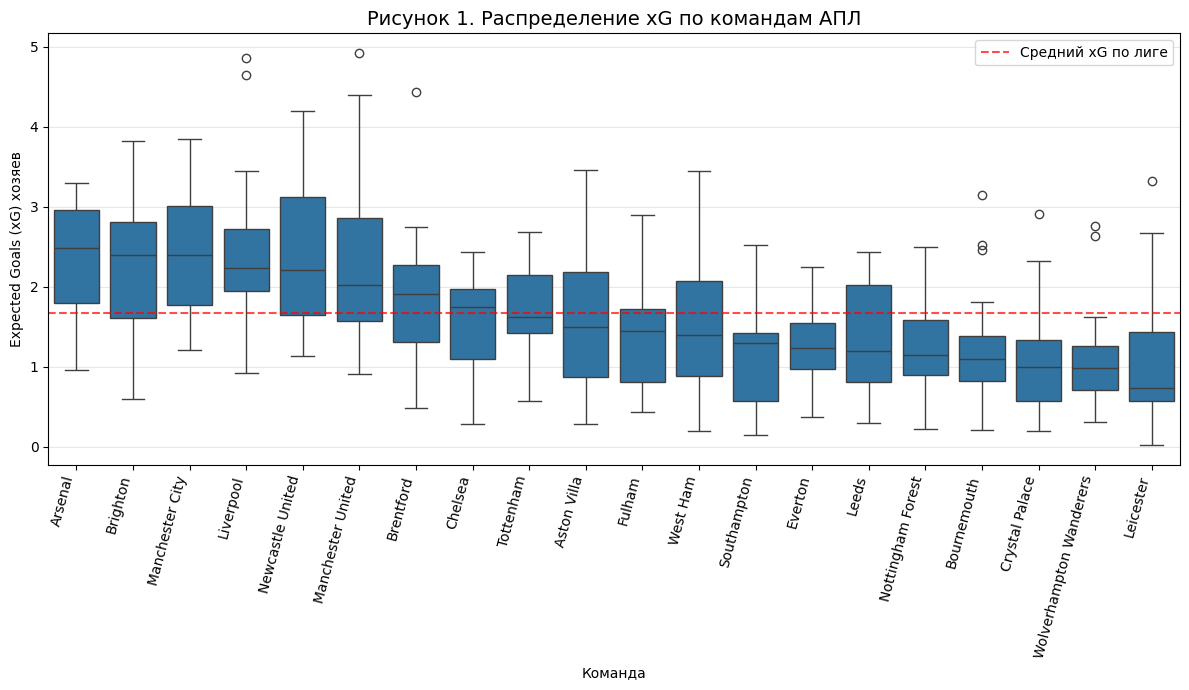

Построен бокс-плот для 20 команд АПЛ


In [10]:
# ====================== РИСУНОК 1: Бокс-плоты xG по командам АПЛ ======================

# Фильтруем только матчи АПЛ
epl_data = matches[matches['league'].str.contains('EPL|Premier', na=False, case=False)].copy()

if 'season' in epl_data.columns:
    recent_seasons = epl_data['season'].astype(str).str.contains('2022/2023', na=False)
    plot_data = epl_data[recent_seasons]
else:
    plot_data = epl_data

plt.figure(figsize=(12, 7))

sns.boxplot(data=plot_data, 
            x='home_team', 
            y='home_xg', 
            order=plot_data.groupby('home_team')['home_xg'].median().sort_values(ascending=False).index)

plt.title('Рисунок 1. Распределение xG по командам АПЛ', fontsize=14)
plt.xlabel('Команда')
plt.ylabel('Expected Goals (xG) хозяев')
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.axhline(plot_data['home_xg'].mean(), color='red', linestyle='--', alpha=0.7, label='Средний xG по лиге')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(vis_dir, 'Рисунок_1_бокс_плот_xG_по_командам_AПЛ.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Построен бокс-плот для {plot_data['home_team'].nunique()} команд АПЛ")

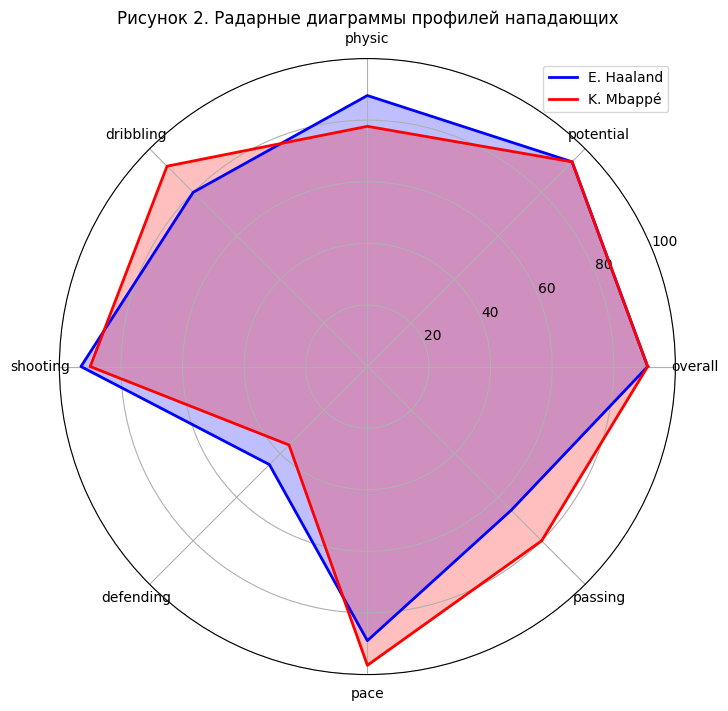

In [11]:
# РИСУНОК 2: Радар (топ-2 игрока по стоимости)
top_players = attrs.nlargest(2, 'value_eur')[['overall', 'potential', 'physic', 'passing',
                                              'dribbling', 'shooting', 'defending', 'pace', 'short_name']]
def plot_radar(ax, row, label, color):
    skills = ['overall', 'potential', 'physic', 'dribbling', 'shooting', 'defending', 'pace', 'passing']
    values = [row.get(s, 50) for s in skills]
    angles = np.linspace(0, 2*np.pi, len(skills), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]
    ax.plot(angles, values, label=label, color=color, linewidth=2)
    ax.fill(angles, values, alpha=0.25, color=color)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['blue', 'red']
for i, (_, row) in enumerate(top_players.iterrows()):
    plot_radar(ax, row, row['short_name'], colors[i])
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(['overall', 'potential', 'physic', 'dribbling', 'shooting', 'defending', 'pace', 'passing'])
ax.set_ylim(0, 100)
ax.set_title('Рисунок 2. Радарные диаграммы профилей нападающих')
ax.legend()
plt.savefig(os.path.join(vis_dir, 'Рисунок_2_радар_игроки.png'), dpi=300, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

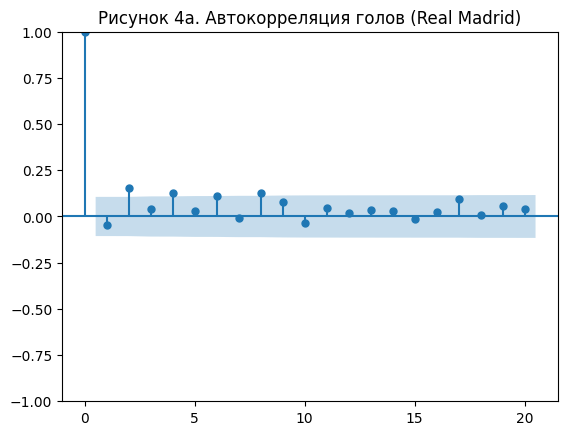

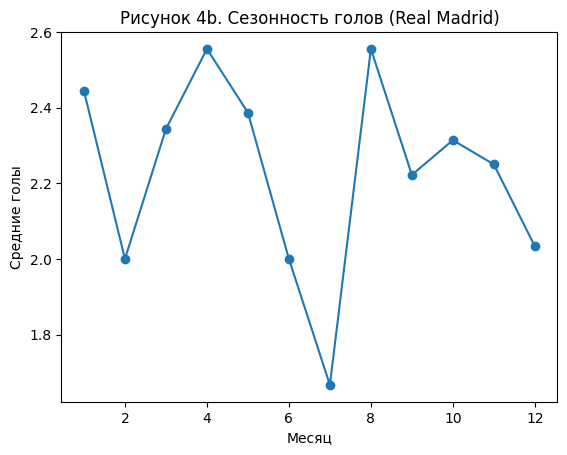

In [12]:
# РИСУНОК 4: Автокорреляция + сезонность 
team_name = 'Real Madrid'
team_matches = matches[(matches['home_team'] == team_name) | (matches['away_team'] == team_name)].copy()
if len(team_matches) > 0:
    team_matches = team_matches.sort_values('date')
    team_matches['goals_scored'] = np.where(team_matches['home_team'] == team_name, 
                                            team_matches['home_score'], team_matches['away_score'])
    from statsmodels.graphics.tsaplots import plot_acf
    plt.figure()
    plot_acf(team_matches['goals_scored'], lags=20)
    plt.title(f'Рисунок 4a. Автокорреляция голов ({team_name})')
    plt.savefig(os.path.join(vis_dir, 'Рисунок_4a_автокорреляция.png'), dpi=300)
    plt.show()
    
    team_matches['month'] = pd.to_datetime(team_matches['date']).dt.month
    monthly = team_matches.groupby('month')['goals_scored'].mean()
    plt.figure()
    plt.plot(monthly.index, monthly.values, marker='o')
    plt.title(f'Рисунок 4b. Сезонность голов ({team_name})')
    plt.xlabel('Месяц')
    plt.ylabel('Средние голы')
    plt.savefig(os.path.join(vis_dir, 'Рисунок_4b_сезонность.png'), dpi=300)
    plt.show()

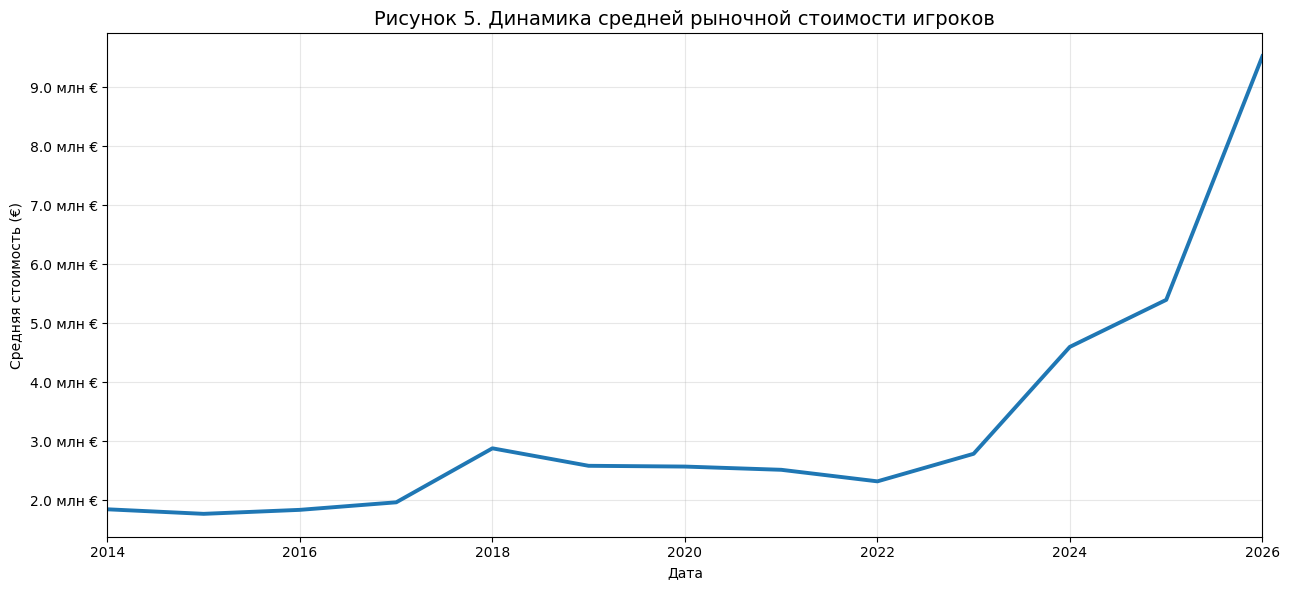

In [16]:
# ====================== РИСУНОК 5: Динамика средней рыночной стоимости ======================
valuations['date'] = pd.to_datetime(valuations['date'], errors='coerce')

valuations_filtered = valuations[valuations['date'] >= '2014-01-01'].copy()

monthly_value = valuations_filtered.groupby(
    valuations_filtered['date'].dt.to_period('Y')
)['market_value_in_eur'].mean()

plt.figure(figsize=(13, 6))
plt.plot(monthly_value.index.to_timestamp(), monthly_value.values, linewidth=2.8)

plt.title('Рисунок 5. Динамика средней рыночной стоимости игроков', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость (€)')
plt.grid(True, alpha=0.3)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f} млн €'))

plt.xlim(pd.Timestamp('2014-01-01'), monthly_value.index.max().to_timestamp())

plt.tight_layout()
plt.savefig(os.path.join(vis_dir, 'Рисунок_5_динамика_стоимости.png'), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("Все таблицы и графики сохранены в папке 'Визуализация'.")

Все таблицы и графики сохранены в папке 'Визуализация'.
